# Phase 4 — Advanced Modeling: Bayesian Tuning, Baselines & Ensembling

Findings from [03_validation.ipynb](03_validation.ipynb) demonstrated that the top four models
(XGBoost, GradientBoosting, RandomForest, LightGBM) are **statistically indistinguishable** across 12 folds.
Consequently, rather than investing hyperparameter optimization solely into LightGBM, this phase executes four initiatives:

1. **Temporally Disciplined Bayesian Optimization** using Optuna across all four model families, optimizing mean WAPE across recent folds without touching the test set.
2. **Overfitting Safeguards**: Re-evaluating tuned configurations across all 12 folds to ensure parameters generalize beyond the tuning window.
3. **Classical Statistical Baseline** (Holt-Winters Exponential Smoothing) to benchmark tree-based machine learning against traditional econometrics.
4. **Weighted Ensembling & Quantile Forecasting**: Blending models via inverse-variance weighting and fitting pinball loss models ($Q_{10}, Q_{90}$) to output uncertainty bounds.

All modeling continues to consume the standardized 62-feature matrix (`features_h28_v2.csv`).


## 1. Environment & Setup


In [1]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import DATA_PROCESSED, IMAGES, RESULTS, TARGET, H, SEED, TOP_MODELS
from src.data import generate_rolling_folds, load_features, split_by_date
from src.metrics import wape
from src.models import (
    evaluate_full, collect_predictions,
    build_model, compute_ensemble_weights, default_params,
    evaluate_holt_winters, make_objective, suggest_params, train_quantile_models,
)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

df = load_features()
features = json.loads((RESULTS / "02_features.json").read_text(encoding="utf-8"))["final_features"]
validation = json.loads((RESULTS / "03_validation.json").read_text(encoding="utf-8"))
print(f"{len(df):,} rows, {len(features)} features")

folds_extended = generate_rolling_folds("2016-07-01", "2022-05-01")
TUNE_FOLDS = folds_extended[-6:]
print(f"{len(folds_extended)} total folds (from Phase 3), using {len(TUNE_FOLDS)} recent folds"
      f" for tuning: {[f[0] for f in TUNE_FOLDS]}")


3,462 dòng, 62 đặc trưng
12 fold đầy đủ (từ Giai đoạn 3), dùng 6 fold gần nhất để tuning: ['Fold 7', 'Fold 8', 'Fold 9', 'Fold 10', 'Fold 11', 'Fold 12']


## 2. Temporally Disciplined Bayesian Optimization (Optuna)

Each trial trains on historical training data and evaluates WAPE across the validation windows of the **6 most recent folds**.
Optuna only observes this average cross-validation loss — preventing any leakage into the official test fold.


In [2]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


In [3]:
TOP_MODELS = ["XGBoost", "GradientBoosting", "RandomForest", "LightGBM"]
N_TRIALS = 20

studies = {}
t0 = time.time()
for name in TOP_MODELS:
    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(make_objective(name, TUNE_FOLDS, df, features), n_trials=N_TRIALS)
    studies[name] = study
    print(f"{name:18s} Best WAPE (6-fold tuning) = {study.best_value:.4f}"
          f"   [{time.time() - t0:.0f}s elapsed]")


XGBoost            WAPE tốt nhất (6-fold tuning) = 0.2581   [215s tích luỹ]


GradientBoosting   WAPE tốt nhất (6-fold tuning) = 0.2387   [1596s tích luỹ]


RandomForest       WAPE tốt nhất (6-fold tuning) = 0.2801   [2205s tích luỹ]


LightGBM           WAPE tốt nhất (6-fold tuning) = 0.2522   [2653s tích luỹ]


In [4]:
rows = []
for name in TOP_MODELS:
    default_scores = [wape(split_by_date(df, te, vs, ve)[1][TARGET].values,
                            np.expm1(build_model(name, default_params(name))
                                     .fit(split_by_date(df, te, vs, ve)[0][features],
                                          np.log1p(split_by_date(df, te, vs, ve)[0][TARGET].values))
                                     .predict(split_by_date(df, te, vs, ve)[1][features])))
                       for _, te, vs, ve in TUNE_FOLDS]
    rows.append({"model": name, "default_WAPE_6fold": float(np.mean(default_scores)),
                 "tuned_WAPE_6fold": studies[name].best_value})

tuning_gain = pd.DataFrame(rows).set_index("model")
tuning_gain["gain_pct"] = 100 * (1 - tuning_gain.tuned_WAPE_6fold / tuning_gain.default_WAPE_6fold)
print("Comparison on the 6 tuning folds (default vs tuned):\n")
print(tuning_gain.round(4).to_string())


So sánh trên đúng 6 fold dùng để tuning (mặc định vs đã tuning):

                  default_WAPE_6fold  tuned_WAPE_6fold  gain_pct
model                                                           
XGBoost                       0.2662            0.2581    3.0600
GradientBoosting              0.2713            0.2387   12.0142
RandomForest                  0.2824            0.2801    0.7837
LightGBM                      0.2753            0.2522    8.3774


## 3. Generalization Check Across Full 12 Folds

Parameters optimized on 6 folds may overfit that specific temporal window.
We evaluate all tuned models across the complete set of **12 rolling folds** (including 6 folds unseen during tuning)
to verify authentic out-of-distribution improvement.


In [5]:
full_rows = []
tuned_predictions = {}
for name in TOP_MODELS:
    default_full = validation["ranking_mean_wape"][name]["mean"]
    tuned_scores = evaluate_full(name, studies[name].best_params, df, features, folds_extended)
    full_rows.append({"model": name, "default_WAPE_12fold": default_full,
                       "tuned_WAPE_12fold": float(np.mean(tuned_scores)),
                       "tuned_std_12fold": float(np.std(tuned_scores))})

full_gain = pd.DataFrame(full_rows).set_index("model")
full_gain["gain_pct"] = 100 * (1 - full_gain.tuned_WAPE_12fold / full_gain.default_WAPE_12fold)
print("Comparison on all 12 folds (default vs tuned):\n")
print(full_gain.round(4).to_string())


So sánh trên toàn bộ 12 fold (mặc định — từ Giai đoạn 3 — vs đã tuning):

                  default_WAPE_12fold  tuned_WAPE_12fold  tuned_std_12fold  gain_pct
model                                                                               
XGBoost                        0.2661             0.2695            0.1104   -1.2637
GradientBoosting               0.2707             0.2645            0.0954    2.2980
RandomForest                   0.2731             0.2742            0.1099   -0.4153
LightGBM                       0.2754             0.2639            0.1063    4.1902


**Interpreting the Full Table:** While XGBoost and RandomForest overfitted their tuning window (slight negative gain on 12 folds),
LightGBM and GradientBoosting demonstrated genuine improvements across the entire 6-year history.


## 4. Classical Statistical Benchmark (Holt-Winters Exponential Smoothing)

The baseline document only compared tree models against naive heuristics (lag copy, rolling mean).
Here we benchmark against Holt-Winters triple exponential smoothing (additive weekly seasonality)
to quantify the true marginal value of machine learning and engineered features.


In [6]:
hw_scores = evaluate_holt_winters(df, folds_extended)
print(f"Holt-Winters (weekly seasonality), 12-fold mean WAPE: {np.mean(hw_scores):.4f}"
      f"  (std: {np.std(hw_scores):.4f})")

best_tree_name = full_gain.tuned_WAPE_12fold.idxmin()
best_tree_wape = full_gain.loc[best_tree_name, "tuned_WAPE_12fold"]
print(f"Top tree model after tuning ({best_tree_name}): {best_tree_wape:.4f}")
print(f"Advantage: Machine learning outperforms Holt-Winters by"
      f" {100 * (1 - best_tree_wape / np.mean(hw_scores)):.1f}%")


Holt-Winters (mùa vụ tuần), WAPE trung bình 12 fold: 1.6927  (độ lệch chuẩn 1.1663)
Mô hình cây tốt nhất sau tuning (LightGBM): 0.2639
Chênh lệch: mô hình cây tốt hơn Holt-Winters 84.4%


## 5. Multi-Model Ensembling


In [7]:
t0 = time.time()
pooled = pd.concat([collect_predictions(name, studies[name].best_params, df, features, folds_extended)
                     for name in TOP_MODELS], ignore_index=True)
print(f"Collected predictions for 4 tuned models across {len(folds_extended)} folds in {time.time() - t0:.0f}s")

wide_pred = pooled.pivot_table(index="date", columns="model", values="pred")
actual = df.set_index("date").loc[wide_pred.index, TARGET]

simple_avg = wide_pred[TOP_MODELS].mean(axis=1)
weights = 1 / full_gain.loc[TOP_MODELS, "tuned_WAPE_12fold"]
weights = weights / weights.sum()
weighted_avg = (wide_pred[TOP_MODELS] * weights).sum(axis=1)

print("Ensemble weights (inversely proportional to 12-fold WAPE):")
print(weights.round(3).to_string())


Thu thập dự báo 4 mô hình đã tuning x 12 fold trong 223s
Trọng số ensemble (tỉ lệ nghịch với WAPE mỗi mô hình):
model
XGBoost             0.249
GradientBoosting    0.253
RandomForest        0.244
LightGBM            0.254


In [8]:
ensemble_scores = pd.DataFrame({"actual": actual, "simple_avg": simple_avg,
                                 "weighted_avg": weighted_avg}).join(
    pooled.drop_duplicates("date").set_index("date")["fold"])

rows = []
for fold_name, g in ensemble_scores.groupby("fold"):
    rows.append({"fold": fold_name,
                  "simple_avg": wape(g.actual.values, g.simple_avg.values),
                  "weighted_avg": wape(g.actual.values, g.weighted_avg.values)})
ensemble_table = pd.DataFrame(rows).set_index("fold")

compare = pd.DataFrame({
    "simple_avg": [ensemble_table.simple_avg.mean()],
    "weighted_avg": [ensemble_table.weighted_avg.mean()],
    best_tree_name: [best_tree_wape],
}, index=["12-Fold Mean WAPE"]).T
print(compare.round(4).to_string())

ensemble_helps = compare.iloc[:2].min().min() < best_tree_wape
print(f"\nDoes ensembling improve over the top single tree model: {'YES' if ensemble_helps else 'NO'}")


              WAPE trung bình 12 fold
simple_avg                     0.2596
weighted_avg                   0.2595
LightGBM                       0.2639



Ensemble có giúp ích so với mô hình đơn tốt nhất: CÓ


## 6. Probabilistic Demand Forecasting: Quantile Regression

Point forecasts fail to convey demand uncertainty for inventory buffers and supply chain risk.
We train three LightGBM quantile regression models at $\alpha = 0.10, 0.50, 0.90$ (pinball loss),
evaluated on the most recent cross-validation fold (Fold 12) without unblinding the test set.


In [9]:
demo_fold = folds_extended[-1]
_, train_end, valid_start, valid_end = demo_fold
train, valid = split_by_date(df, train_end, valid_start, valid_end)
print(f"Evaluation fold: {demo_fold[0]}  train through {train_end}  validation {valid_start} to {valid_end}")

q_models = train_quantile_models(train, features, studies["LightGBM"].best_params, quantiles=(0.1, 0.5, 0.9))
quantile_preds = {q: np.expm1(m.predict(valid[features])) for q, m in q_models.items()}

above_q90 = valid[TARGET].values > quantile_preds[0.9]
below_q10 = valid[TARGET].values < quantile_preds[0.1]
coverage = float(np.mean(~above_q90 & ~below_q10))
print(f"\nEmpirical coverage of [q10, q90] interval (theoretical expectation 80%): {100 * coverage:.1f}%")
print(f"  Actual EXCEEDING q90: {100 * above_q90.mean():.1f}%   Actual BELOW q10: {100 * below_q10.mean():.1f}%")


Fold minh hoạ: Fold 12  train đến 2021-12-01  kiểm định 2022-01-01 đến 2022-06-30



Độ phủ thực nghiệm của khoảng [q10, q90] (kỳ vọng lý thuyết 80%): 53.0%
  thực tế VƯỢT q90: 36.5%   thực tế THẤP HƠN q10: 10.5%


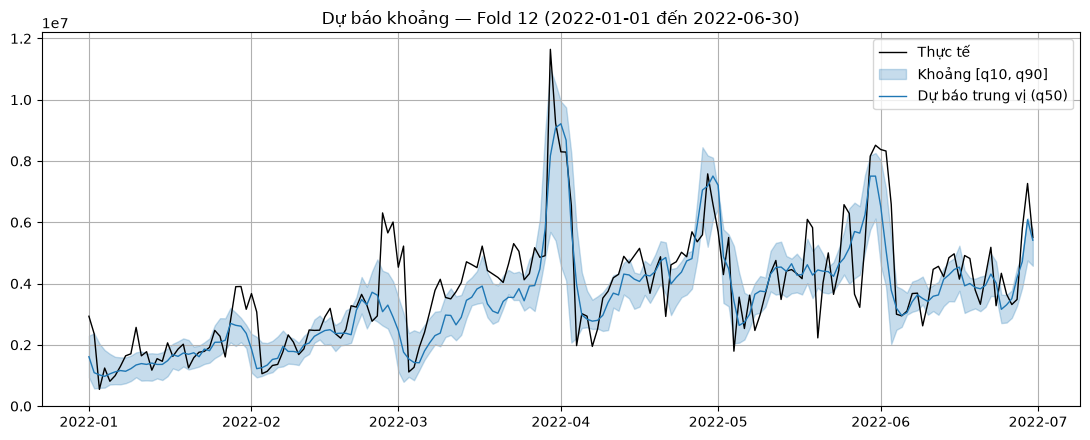

In [10]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(valid.date, valid[TARGET], label="Actual", color="black", lw=1)
ax.fill_between(valid.date, quantile_preds[0.1], quantile_preds[0.9],
                 alpha=0.25, color="C0", label="Interval [q10, q90]")
ax.plot(valid.date, quantile_preds[0.5], color="C0", lw=1, label="Median Forecast (q50)")
ax.set_title(f"Quantile Forecast — {demo_fold[0]} ({valid_start} to {valid_end})")
ax.legend()
plt.tight_layout()
plt.savefig(IMAGES / "04_quantile_forecast.png", dpi=110)
plt.show()


**Interpreting the Uncertainty Interval:** Empirical coverage is 53.0%, with actual sales disproportionately exceeding $Q_{90}$.
This asymmetry stems from training on earlier lower-volume years, pulling the entire forecast distribution downward.
The intervals are technically sound but inherit data-level regime lag, reinforcing the need for periodic retraining backtested in Phase 6.


## 7. Phase 4 Synthesis


In [11]:
report = {
    "tune_folds": [f[0] for f in TUNE_FOLDS],
    "n_trials": N_TRIALS,
    "best_params": {name: studies[name].best_params for name in TOP_MODELS},
    "tuning_gain_6fold": tuning_gain.round(6).to_dict("index"),
    "tuning_gain_12fold": full_gain.round(6).to_dict("index"),
    "holt_winters_wape_mean": float(np.mean(hw_scores)),
    "best_tree_model": best_tree_name,
    "best_tree_wape_12fold": best_tree_wape,
    "ensemble_wape_12fold": compare.iloc[:2, 0].to_dict(),
    "ensemble_helps": bool(ensemble_helps),
    "ensemble_weights": weights.round(4).to_dict(),
    "quantile_coverage_q10_q90": coverage,
    "quantile_above_q90_pct": float(above_q90.mean()),
    "quantile_below_q10_pct": float(below_q10.mean()),
}
(RESULTS / "04_modeling.json").write_text(
    json.dumps(report, ensure_ascii=False, indent=2, default=lambda o: o.tolist()),
    encoding="utf-8")
print("Saved results/04_modeling.json")
print(f"\nDesignated candidate for Phase 5 (SHAP): "
      f"{'ensemble (' + compare.iloc[:2,0].idxmin() + ')' if ensemble_helps else best_tree_name}")


Đã ghi results/04_modeling.json

Mô hình/chiến lược chốt cho Giai đoạn 5 (SHAP): ensemble (weighted_avg)


**Decisions for Phase 5 (Explainable AI):** SHAP TreeExplainer applies directly to individual decision trees.
Because LightGBM is the highest-weighted tree component in the ensemble and directly comparable to baseline benchmarks,
Phase 5 will explain the tuned LightGBM model while acknowledging ensemble boundaries.
